In [1]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
import os
import matplotlib
import matplotlib.pyplot as plt
os.environ["TF_USE_DIRECTML"] = "1"

print("DirectML Devices:", tf.config.list_physical_devices('GPU'))  # Should show your GPU

DirectML Devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
def extract_patches(image, patch_size=56, stride=14):
    """Extract overlapping patches from an image"""
    patches = tf.image.extract_patches(
        images=tf.expand_dims(image, 0), # artificially increase the dimensions to (1, w, h, c), necessary for extract function
        sizes=[1, patch_size, patch_size, 1],
        strides=[1, stride, stride, 1],
        rates=[1, 1, 1, 1], # rates is used for dilatation 
        padding='VALID' # Only use fully contained patches
    )
    return tf.reshape(patches, [-1, patch_size, patch_size, image.shape[-1]]) # reshape patches to (num_patches, w, h, c)

# Example usage:
# n = 224
# images = np.array([[[x * n + y + 1] for y in range(n)] for x in range(n)]) 
# print(extract_patches(images, 64, 16).shape) # outputs 169,32,32,1

In [3]:
class PatchBagGenerator(tf.keras.utils.Sequence):
    def __init__(self, image_arrays, labels, patch_size=56, stride=14, batch_size=32):
        """
        Args:
            image_arrays: Array of preloaded images (h,w,c)
            labels: Corresponding labels
            patch_size: Size of square patches
            stride: Step between patches
            batch_size: Number of images per batch
        """
        self.image_arrays = image_arrays
        self.labels = labels
        self.patch_size = patch_size
        self.stride = stride
        self.batch_size = batch_size
        self.num_samples = len(image_arrays)
        self.indices = np.arange(self.num_samples)
        assert self.image_arrays.shape == (self.num_samples, 224, 224, 1), "Image arrays shape mismatch: {} vs {}".format(image_arrays.shape, (self.num_samples, 224, 224, 1))
                
    def __len__(self):
        return int(np.ceil(self.num_samples / self.batch_size))
    
    def __getitem__(self, index):
        batch_indices = self.indices[index*self.batch_size:(index+1)*self.batch_size] # retrieve indices for current batch index
        batch_images = [self.image_arrays[i] for i in batch_indices] # retrieve images for current batch
        batch_labels = [self.labels[i] for i in batch_indices] # retrieve labels for current batch
        
        # Process each image into patches
        batch_bags = []
        for img in batch_images:
            batch_bags.append(extract_patches(img, patch_size=self.patch_size, stride=self.stride)) 
                
        return np.array(batch_bags), np.array(batch_labels)
    
    def on_epoch_end(self):
        np.random.shuffle(self.indices) # randomize batches for next epoch

In [4]:
def custom_augmented_generator(datagen, x, y, batch_size):
    gen = datagen.flow(x, y, batch_size=batch_size)
    for x_batch, y_batch in gen:
        x_batch_aug = []
        for img in x_batch:
            # Random horizontal flip with 50% chance
            img = tf.image.random_flip_left_right(img)

            # Random brightness adjustment
            img = tf.image.random_brightness(img, max_delta=0.05)

            # Random contrast adjustment
            img = tf.image.random_contrast(img, lower=0.95, upper=1.05)

            # Add Gaussian noise
            noise = tf.random.normal(shape=tf.shape(img), mean=0.0, stddev=10)
            img = img + noise
            
            x_batch_aug.append(img)
               
        x_batch_aug = tf.stack(x_batch_aug)
        yield x_batch_aug.numpy(), y_batch

In [5]:
def extract_generator_data(generator):
    """Convert generator output to arrays"""
    images, labels = [], []
    generator.reset() # ensure to retrieve all data from generator start
    for i in range(len(generator)):
        batch_img, batch_lbl = generator[i]
        images.append(batch_img)
        labels.append(batch_lbl)
    return np.vstack(images), np.vstack(labels)

def extract_from_python_generator(generator, steps):
    images, labels = [], []
    for _ in range(steps):
        batch_img, batch_lbl = next(generator)
        images.append(batch_img)
        labels.append(batch_lbl)
    return np.vstack(images), np.vstack(labels)

# initialize generator for data retrieval
train_datagen = ImageDataGenerator(
    validation_split=0.2
)

train_path = "/Users/andelagrizelj/uni/Master/praktikum/code/data/preprocessed/Training"

# create training and validation generators from data
train_dir_gen = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='training',
    color_mode="grayscale"
)

val_dir_gen = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='validation',
    color_mode="grayscale"
)

# convert generators to Data array containing images and label vector containing classes
X_train, y_train = extract_generator_data(train_dir_gen)
X_val, y_val = extract_generator_data(val_dir_gen)

# Augmenting train data
train_gen_aug = custom_augmented_generator(train_datagen, X_train, y_train, batch_size=16)

# Control number of augmented images with variable steps
total_samples = len(X_train)
augmented_samples = int(total_samples * 0.3)
batch_size = 16
steps_aug = int(np.ceil(augmented_samples / batch_size))

# convert augmentation generator to Data array
steps = int(np.ceil(len(X_train) / 16))
X_aug, y_aug = extract_from_python_generator(train_gen_aug, steps_aug)


print("Size before augmentation: " + str(X_train.shape))
X_train = np.concatenate([X_train, X_aug], axis=0)
y_train = np.concatenate([y_train, y_aug], axis=0)

# Shuffle combined dataset
idx = np.arange(len(X_train))
np.random.shuffle(idx)
X_train = X_train[idx]
y_train = y_train[idx]

print("Size after augmentation: " + str(X_train.shape))


print("Class indices:", train_dir_gen.class_indices)

Found 2297 images belonging to 4 classes.
Found 573 images belonging to 4 classes.


2025-07-28 08:29:29.205973: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2025-07-28 08:29:29.206031: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-07-28 08:29:29.206041: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-07-28 08:29:29.206068: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-07-28 08:29:29.206081: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Size before augmentation: (2297, 224, 224, 1)
Size after augmentation: (3001, 224, 224, 1)
Class indices: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}


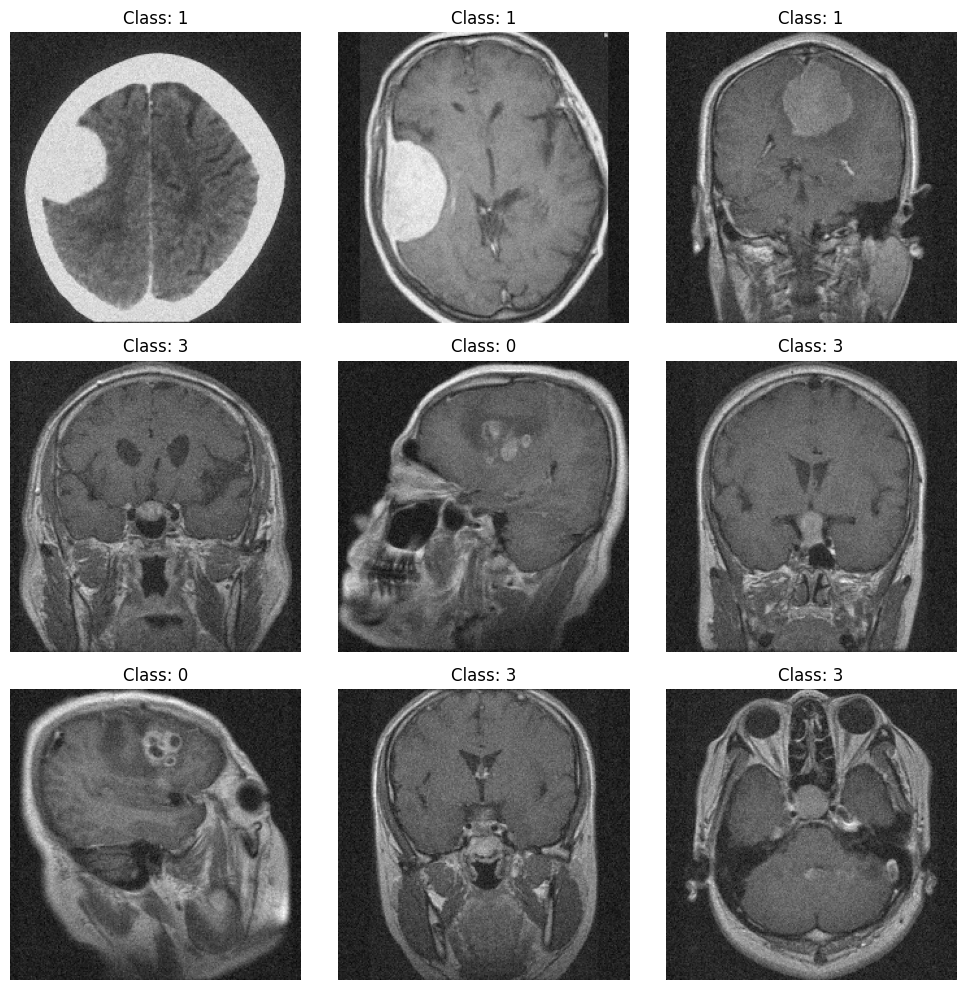

In [6]:
# Show 9 augmented images - only for visualization
num_images_to_show = 9
plt.figure(figsize=(10, 10))

for i in range(num_images_to_show):
    plt.subplot(3, 3, i + 1)
    img = X_aug[i].squeeze()
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.title(f"Class: {np.argmax(y_aug[i])}")

plt.tight_layout()
plt.show()

In [7]:
def create_basic_mil_model(patch_size=64, num_classes=4):
    """Create MIL model using vgg"""
    
    # Instance-level model (processes individual patches)
    instance_input = layers.Input(shape=(patch_size, patch_size, 1))
    x = layers.Concatenate(axis=-1)([instance_input]*3)
    
    # Feature extractor
    vgg = VGG16(weights='imagenet', include_top=False, input_shape=(patch_size, patch_size, 3), pooling='avg')
    # vgg.trainable = False # TODO look up what this does
    print(len(vgg.layers))
    for layer in vgg.layers[:15]:  # Freeze more layers
        layer.trainable = False
        
    x = vgg(x)
    x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.Dropout(0.3)(x)
    instance_output = layers.LayerNormalization()(x)
    
    instance_model = Model(instance_input, instance_output)
    # TODO "saliency"
    
    # Bag-level model applying the instance level model to each of the patches (using TimeDistributed)
    bag_input = layers.Input(shape=(None, patch_size, patch_size, 1))
    x = layers.TimeDistributed(instance_model)(bag_input)
  
    bag_representation = layers.GlobalMaxPooling1D()(x)
    # bag_representation = layers.Dropout(0.5)(x)
    
    # Classification head
    output = layers.Dense(num_classes, activation='softmax')(bag_representation)
    
    return Model(bag_input, output)

In [8]:

# Create and compile model
model = create_basic_mil_model(patch_size=56, num_classes=4)
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Create data generators 
train_mil_gen = PatchBagGenerator(
    image_arrays=X_train,
    labels=y_train,
    patch_size=56,
    stride=14,
    batch_size=16
)

val_mil_gen = PatchBagGenerator(
    image_arrays=X_val,
    labels=y_val,
    patch_size=56,
    stride=14,
    batch_size=16
)

# Train
history = model.fit(
    train_mil_gen,
    validation_data=val_mil_gen,
    epochs=1
)

20


/Users/andelagrizelj/praktikum/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
2025-07-14 18:03:35.931305: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


188/188 ━━━━━━━━━━━━━━━━━━━━ 1403s 7s/step - accuracy: 0.3360 - loss: 2.6284 - val_accuracy: 0.5201 - val_loss: 1.2760


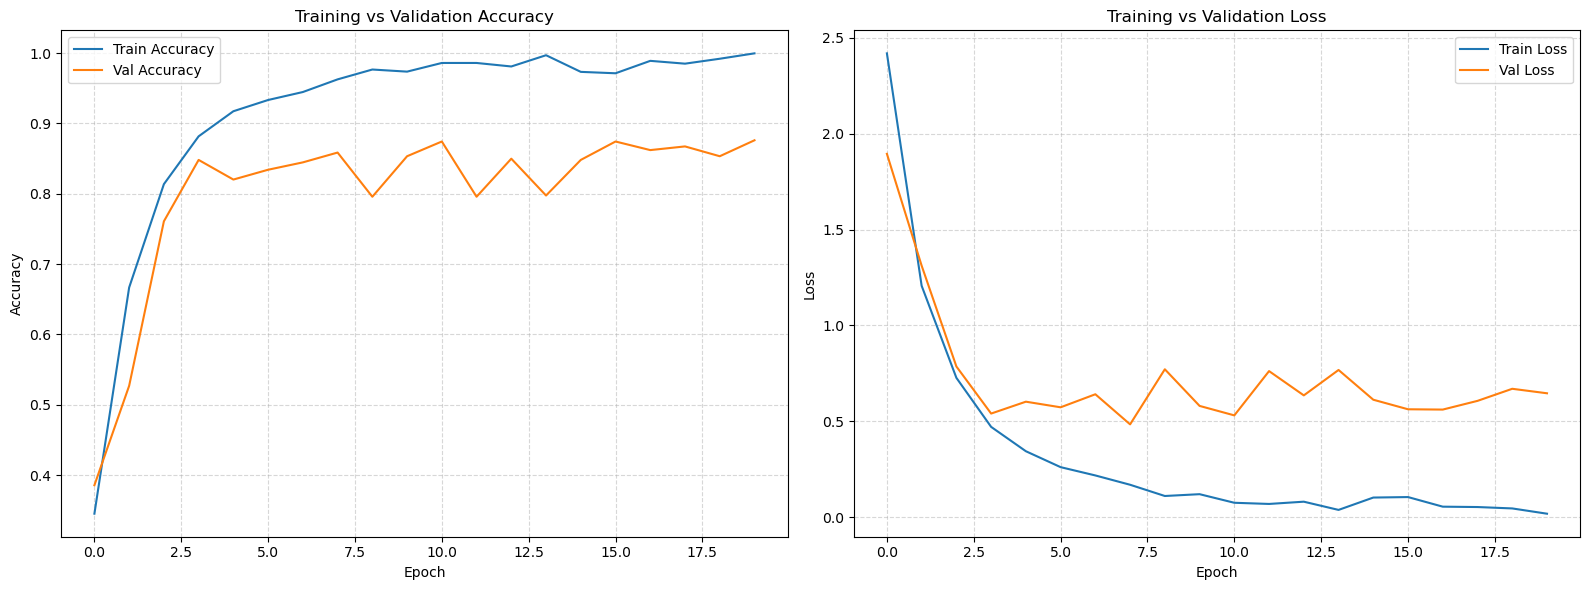

In [118]:
# Set global font sizes when used for presentation
# plt.rcParams.update({
#     'axes.titlesize': 18,    # Title font size
#     'axes.labelsize': 16,    # X and Y axis label size
#     'xtick.labelsize': 14,   # X-axis tick label size
#     'ytick.labelsize': 14,   # Y-axis tick label size
#     'legend.fontsize': 14,   # Legend font size
# })
plt.rcParams.update(matplotlib.rcParamsDefault) # else restore default parameters

# Create figure with 1 row and 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Accuracy ---
ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_title('Training vs Validation Accuracy')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# --- Plot 2: Loss ---
ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Training vs Validation Loss')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

# Improve layout and save
plt.tight_layout()
# plt.savefig('figures/train_mil+15freeze.png')
plt.show()
plt.close()

# TODO implement confusion matrix

In [6]:
import matplotlib.patches as patches

def show_max_patch(batch_index, X_test, class_names, y_pred, y_test, test_mil_gen, patch_feature_model):
    
    batch_size = 16
    patch_size = 56
    stride = 14
    img_height, img_width = 224, 224
    grid_size = (img_height - patch_size) // stride + 1
    bags, labels = test_mil_gen[batch_index]

    # Predict per-patch features
    patch_features = patch_feature_model.predict(bags)  # shape: (batch_size, num_patches, feature_dim)

    # Find most activated patch per image
    patch_activations = np.max(patch_features, axis=-1)  # shape: (batch_size, num_patches)
    most_activated_indices = np.argmax(patch_activations, axis=1)
    
    for i in range(bags.shape[0]):
        global_img_idx = batch_index * batch_size + i

        original_img = X_test[global_img_idx].squeeze()
        max_idx = most_activated_indices[i]

        # Compute grid coordinates
        row = max_idx // grid_size
        col = max_idx % grid_size
        y = row * stride
        x = col * stride

        fig, ax = plt.subplots(figsize=(5, 5))
        ax.imshow(original_img, cmap='gray')

        rect = patches.Rectangle((x, y), patch_size, patch_size,
                                 linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)

        true_class = class_names[np.argmax(y_test[global_img_idx])]
        pred_class = class_names[np.argmax(y_pred[global_img_idx])]
        plt.title(f"Most Activated Patch\nTrue: {true_class}, Pred: {pred_class}")
        ax.axis('off')
        plt.show()

        
def show_mean_patch(batch_index, X_test, class_names, y_pred, y_test, test_mil_gen, patch_feature_model):
    top_k = 4  # Number of top activated patches
    patch_size = 56
    stride = 14
    img_height, img_width = 224, 224
    grid_size = (img_height - patch_size) // stride + 1
    
    batch_size = 16
    bags, labels = test_mil_gen[batch_index]

    # Predict per-patch features
    patch_features = patch_feature_model.predict(bags)  # shape: (batch_size, num_patches, feature_dim)

    # Find most activated patch per image
    patch_activations = np.max(patch_features, axis=-1)  # shape: (batch_size, num_patches)

    for i in range(bags.shape[0]):
        global_img_idx = batch_index * batch_size + i

        original_img = X_test[global_img_idx].squeeze()

        # Get top K indices of most activated patches
        top_k_indices = np.argsort(patch_activations[i])[-top_k:]  # shape: (4,)

        # Convert each patch index to (x, y) coordinate
        coords = []
        for idx in top_k_indices:
            row = idx // grid_size
            col = idx % grid_size
            y = row * stride
            x = col * stride
            coords.append((x, y))

        # Calculate mean coordinate
        mean_x = int(np.mean([c[0] for c in coords]))
        mean_y = int(np.mean([c[1] for c in coords]))

        # Center the rectangle around the mean coordinate
        rect_x = max(0, mean_x - patch_size // 2)
        rect_y = max(0, mean_y - patch_size // 2)

        # Ensure it doesn't go out of image bounds
        rect_x = min(rect_x, img_width - patch_size)
        rect_y = min(rect_y, img_height - patch_size)

        fig, ax = plt.subplots(figsize=(5, 5))
        ax.imshow(original_img, cmap='gray')

        rect = patches.Rectangle((rect_x, rect_y), patch_size, patch_size,
                                 linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)

        true_class = class_names[np.argmax(y_test[global_img_idx])]
        pred_class = class_names[np.argmax(y_pred[global_img_idx])]
        plt.title(f"Top-{top_k} Activated Patch Region\nTrue: {true_class}, Pred: {pred_class}")
        ax.axis('off')
        plt.show()

In [7]:
### Testing model on test data - using confusion matrix
from tensorflow.keras.models import load_model
import matplotlib.patches as patches


# Create test generator
test_path = f"/Users/andelagrizelj/uni/Master/praktikum/code/data/preprocessed/Testing"
test_datagen = ImageDataGenerator()
test_dir_gen = test_datagen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    color_mode="grayscale",
    shuffle=False  # Important for confusion matrix
)

# Convert test generator to arrays
X_test, y_test = extract_generator_data(test_dir_gen)

# Create test MIL generator
test_mil_gen = PatchBagGenerator(
    image_arrays=X_test,
    labels=y_test,
    patch_size=56,
    stride=14,
    batch_size=16
)

# Get predictions
model = load_model("../mil_model.h5")
y_pred = model.predict(test_mil_gen)


# Build patch feature model
patch_feature_model = Model(
    inputs=model.input,
    outputs=model.get_layer("time_distributed").output  # -3 = TimeDistributed output layer
)


y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

Found 394 images belonging to 4 classes.


/Users/andelagrizelj/praktikum/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
2025-07-28 08:29:49.664886: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


25/25 ━━━━━━━━━━━━━━━━━━━━ 220s 7s/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


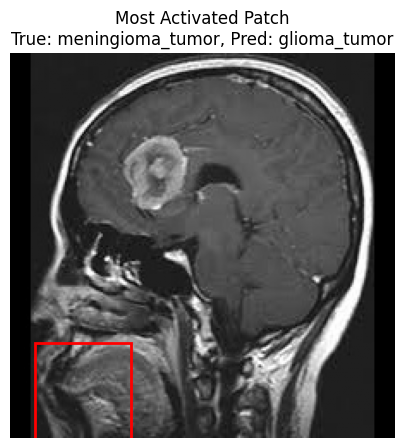

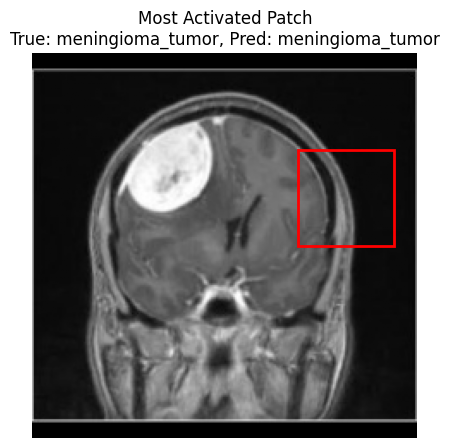

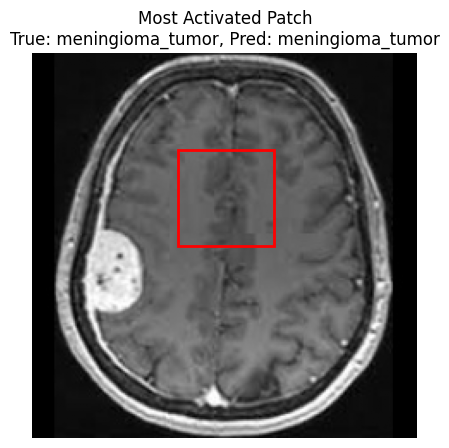

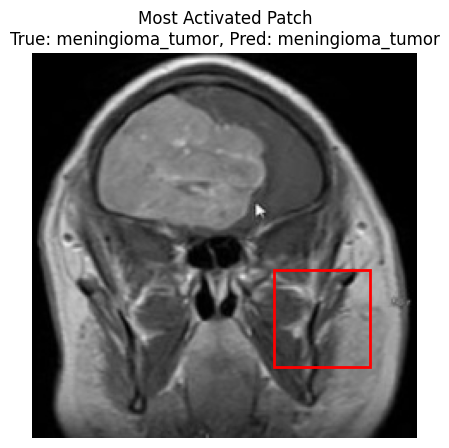

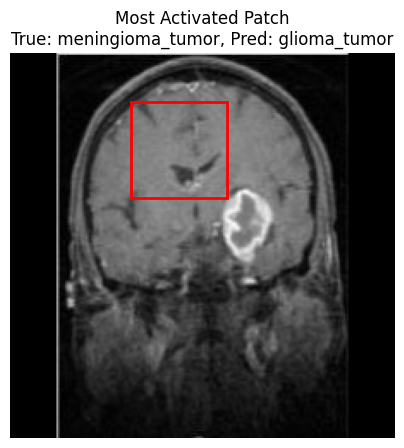

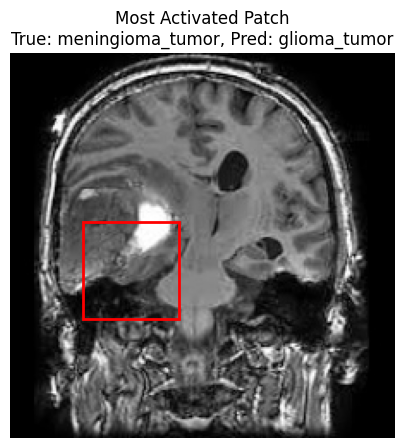

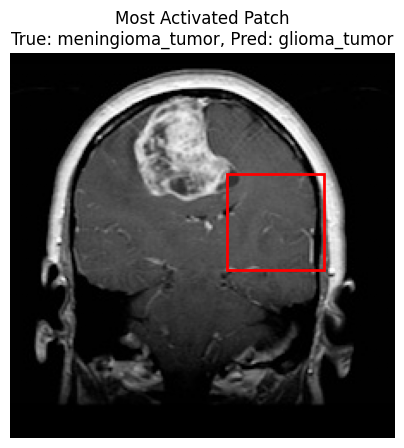

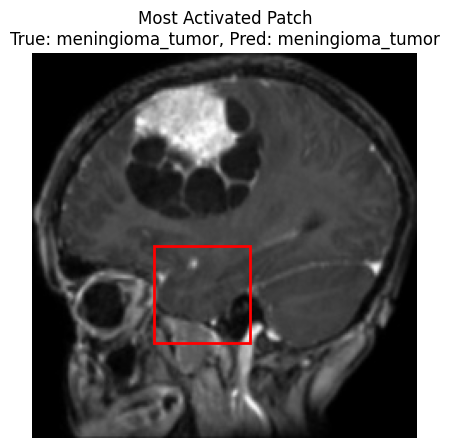

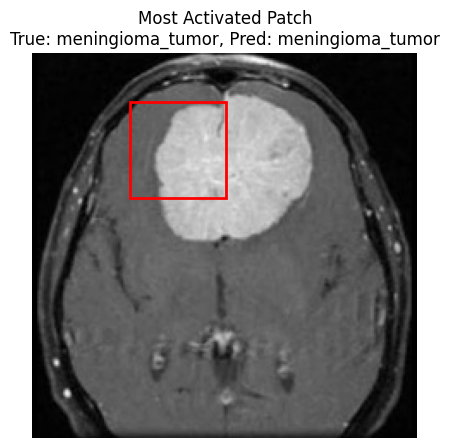

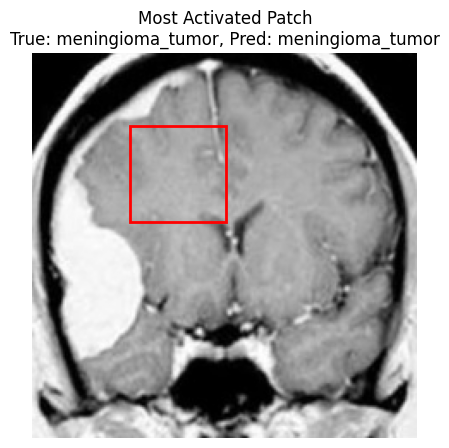

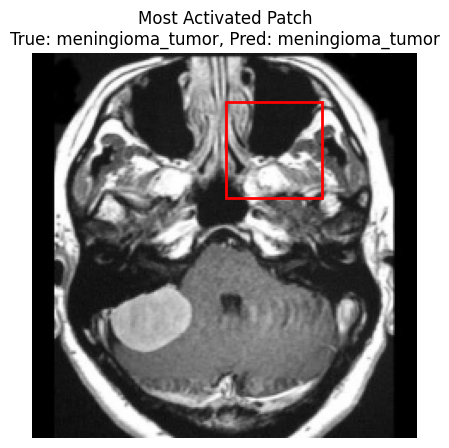

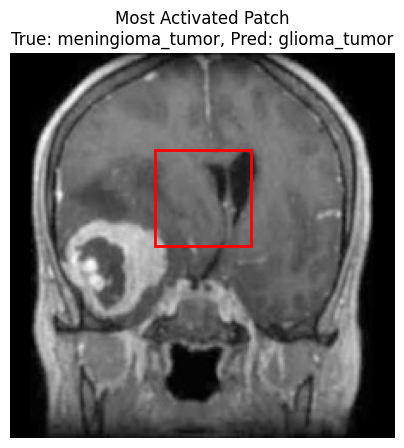

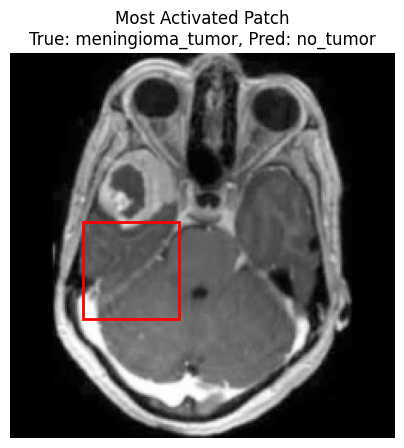

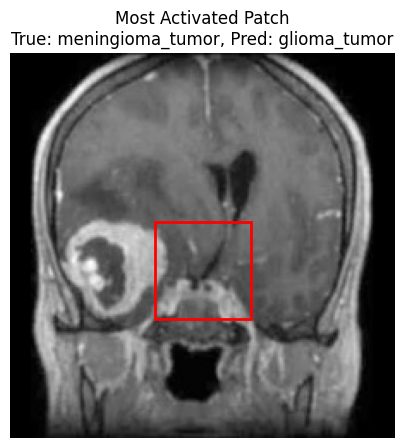

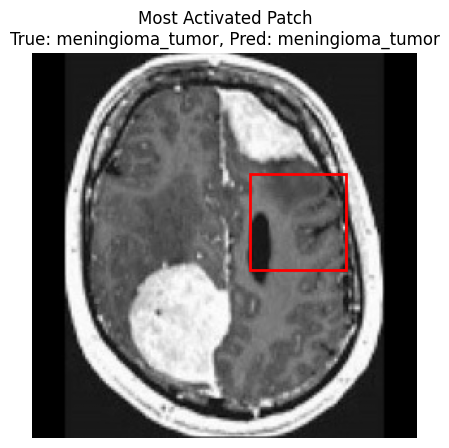

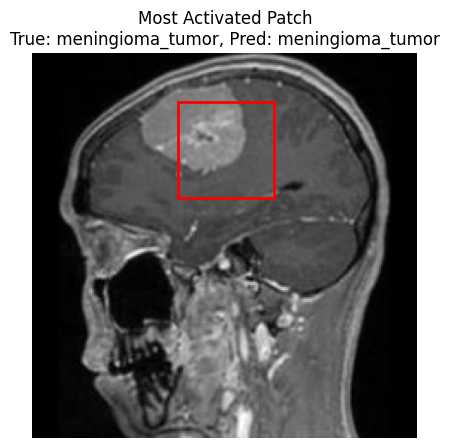

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


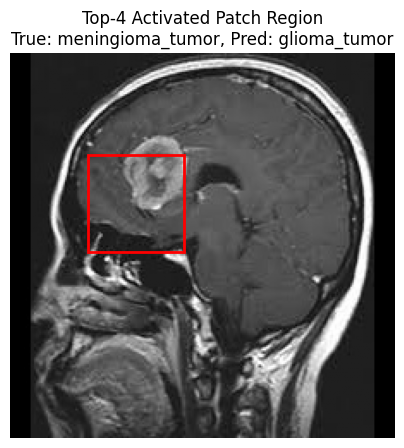

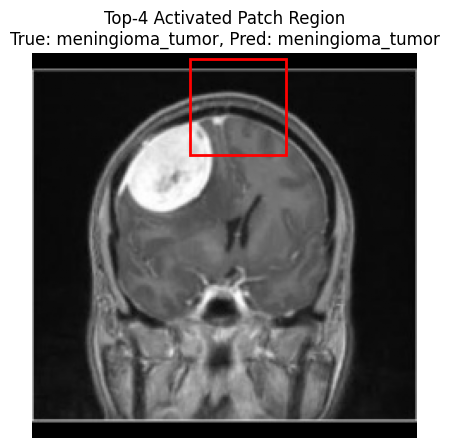

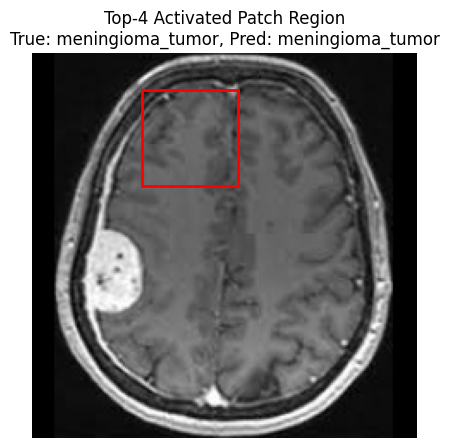

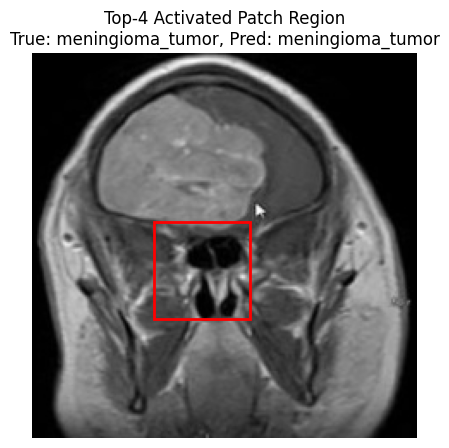

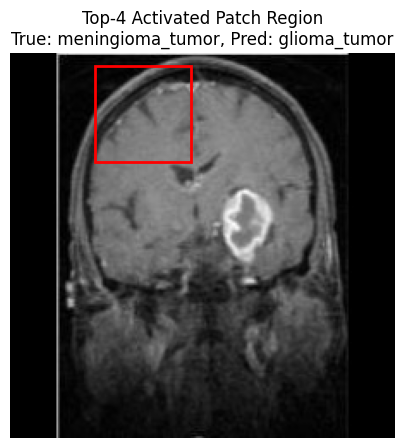

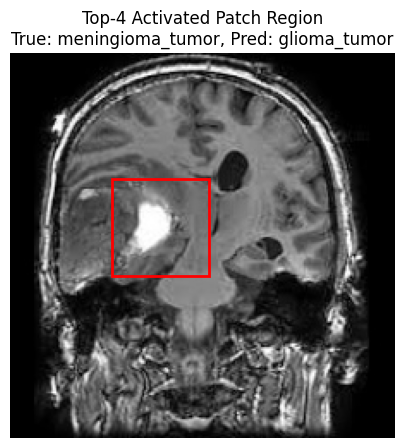

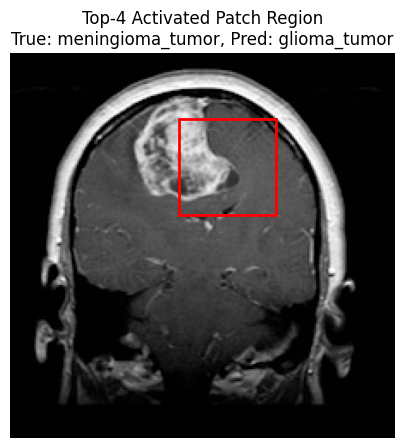

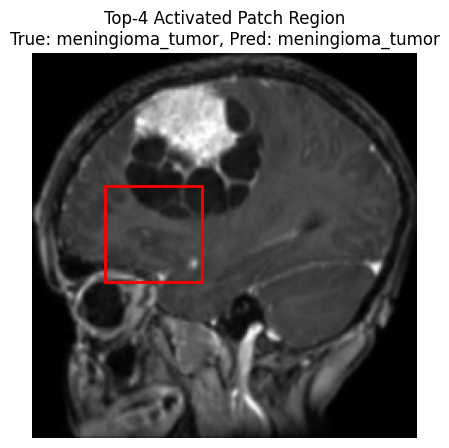

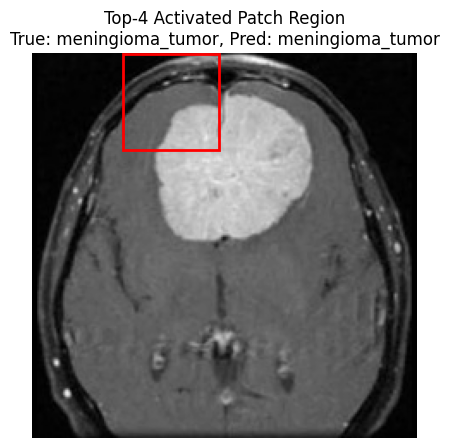

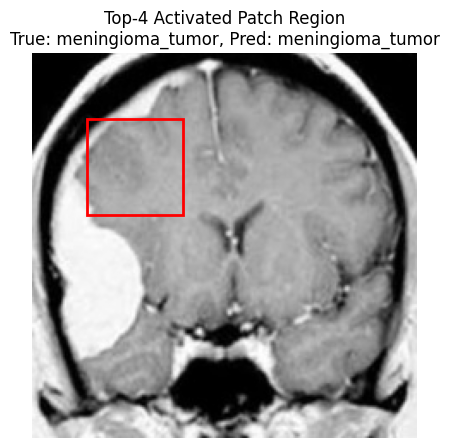

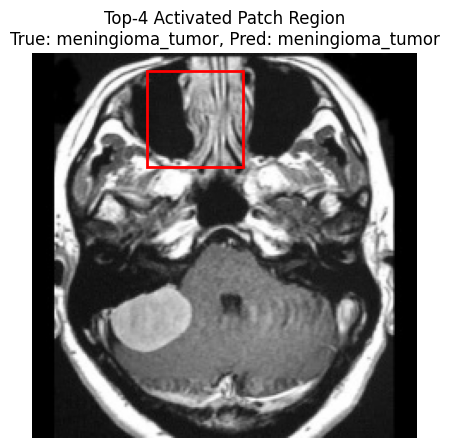

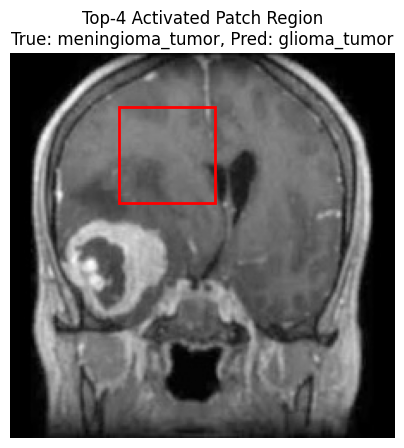

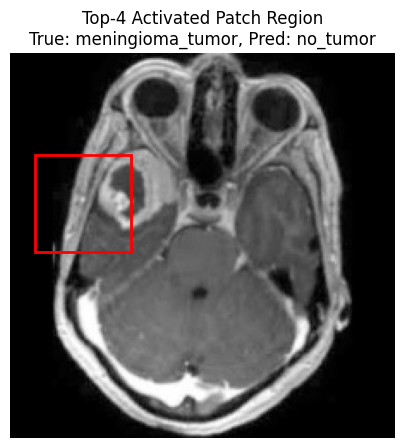

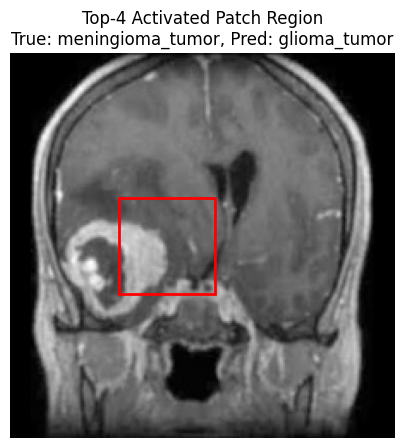

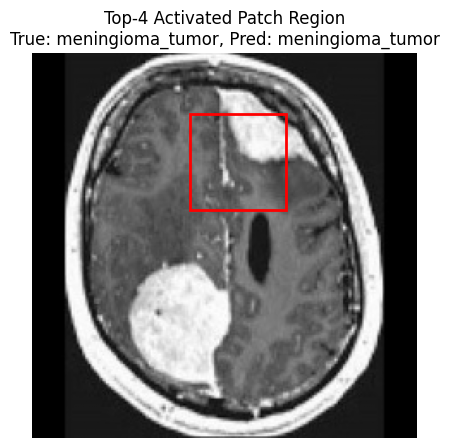

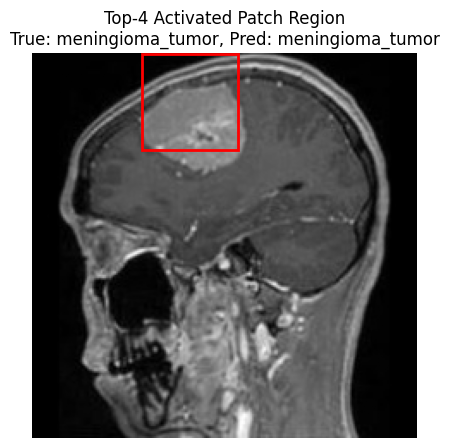

In [13]:
batch_index=10
class_names = list(test_dir_gen.class_indices.keys())

show_max_patch(batch_index, X_test, class_names, y_pred, y_test, test_mil_gen, patch_feature_model)
    
show_mean_patch(batch_index, X_test, class_names, y_pred, y_test, test_mil_gen, patch_feature_model)